In [1]:
import music21 as m21
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN
from scipy.signal import find_peaks

score = m21.converter.parse("~/Dvorak_no9_colored_cut.mxl")
#score = score.expandRepeats()
#score.show()
# Get all parts
parts = [part for part in score.parts]

#score.show()
print(parts)



[<music21.stream.Part Flauti I. II.>, <music21.stream.Part Oboi I. II.>, <music21.stream.Part Clarinetti I. II. A>, <music21.stream.Part Fagotti I. II.>, <music21.stream.Part Corni I. II. E>, <music21.stream.Part Corni III. IV. E>, <music21.stream.Part Trombe I. II. E>, <music21.stream.Part Tromboni I. II.>, <music21.stream.Part Tromboni III.>, <music21.stream.Part Timpani E, H>, <music21.stream.Part Violini I.>, <music21.stream.Part Violini II.>, <music21.stream.Part Viole>, <music21.stream.Part Violoncelli>, <music21.stream.Part Contrabassi>]


In [2]:
def parse_musicxml(file_path):
    """Parse MusicXML file and extract relevant information"""
    score = m21.converter.parse(file_path)
    
    # Get all parts
    parts = [part for part in score.parts]
    
    # Extract musical events
    events = extract_musical_events(score)
    
    return score, parts, events

In [3]:
def extract_musical_events(score):
    """
    Extract musical events from a music21 score that might indicate phrase boundaries.
    
    Args:
        score: music21 Score object
    
    Returns:
        events: List of dictionaries containing event information
    """
    events = []
    
    # Get all parts from the score
    parts = score.parts
    
    # Iterate through all elements in the score to find potential boundary markers
    for part_idx, part in enumerate(parts):
        # We'll look at measures to find barlines and other structural markers
        for measure in part.getElementsByClass(m21.stream.Measure):
            measure_offset = measure.offset
            
            # Check for double barlines (strong structural markers)
            if measure.rightBarline:
                if measure.rightBarline.type in ['double', 'final', 'heavy', 'light-heavy']:
                    events.append({
                        'type': 'double_barline',
                        'time': measure_offset + measure.duration.quarterLength,
                        'part': part_idx,
                        'measure': measure.number
                    })
            
            # Check for key changes
            for key in measure.getElementsByClass(m21.key.Key):
                events.append({
                    'type': 'key_change',
                    'time': measure_offset,
                    'part': part_idx,
                    'measure': measure.number,
                    'key': key
                })
            
            # Check for time signature changes
            for ts in measure.getElementsByClass(m21.meter.TimeSignature):
                events.append({
                    'type': 'time_signature_change',
                    'time': measure_offset,
                    'part': part_idx,
                    'measure': measure.number,
                    'time_signature': ts
                })
            
            # Check for rehearsal marks and text expressions
            for expression in measure.getElementsByClass(m21.expressions.TextExpression):
                text = expression.content.lower()
                if any(marker in text for marker in ['verse', 'chorus', 'refrain', 'bridge', 'solo', 'trio', 'coda', 'd.c.', 'd.s.']):
                    events.append({
                        'type': 'section_marker',
                        'time': measure_offset,
                        'part': part_idx,
                        'measure': measure.number,
                        'text': text
                    })
            
            # Check for fermatas
            for note in measure.notesAndRests:
                if hasattr(note, 'expressions') and note.expressions:
                    for expr in note.expressions:
                        if isinstance(expr, m21.expressions.Fermata):
                            events.append({
                                'type': 'fermata',
                                'time': note.offset + measure_offset,
                                'part': part_idx,
                                'measure': measure.number
                            })
    
    # Also look for grand pauses (rests in all parts at the same time)
    # This is more complex and requires analyzing all parts simultaneously
    all_notes_and_rests = []
    for part_idx, part in enumerate(parts):
        for element in part.flat.notesAndRests:
            all_notes_and_rests.append({
                'element': element,
                'part': part_idx,
                'offset': element.offset,
                'duration': element.duration.quarterLength
            })
    
    # Sort by time
    all_notes_and_rests.sort(key=lambda x: x['offset'])
    
    # Find times where all parts have rests
    max_time = max(item['offset'] for item in all_notes_and_rests)
    time_grid = np.arange(0, max_time + 0.25, 0.25)  # Check every 16th note
    
    for time in time_grid:
        # Check what each part is doing at this time
        part_activities = []
        for part_idx in range(len(parts)):
            # Find elements that are active at this time
            active_elements = [item for item in all_notes_and_rests 
                              if item['part'] == part_idx and 
                              item['offset'] <= time < item['offset'] + item['duration']]
            
            if active_elements:
                element = active_elements[0]['element']
                is_rest = isinstance(element, m21.note.Rest)
                part_activities.append(is_rest)
            else:
                part_activities.append(False)  # No element found, assume not rest
        
        # If all parts are resting at this time, it's a grand pause
        if all(part_activities):
            events.append({
                'type': 'grand_pause',
                'time': time,
                'parts': list(range(len(parts)))
            })
    
    return events

def refine_boundaries_with_events(boundary_times, events, time_grid, max_search=0.5):
    """
    Refine boundaries by snapping them to nearby musical events.
    
    Args:
        boundary_times: Initial boundary times
        events: List of musical events (from extract_musical_events)
        time_grid: Time grid used for feature extraction
        max_search: Maximum distance to search for events (in quarter notes)
    
    Returns:
        refined_boundaries: Refined boundary times
    """
    # Create a list of event times with their types and weights
    event_points = []
    
    # Assign weights to different event types
    event_weights = {
        'grand_pause': 5.0,      # Very strong indicator
        'double_barline': 4.0,   # Strong indicator
        'section_marker': 3.5,   # Strong indicator
        'key_change': 3.0,       # Medium-strong indicator
        'time_signature_change': 3.0,  # Medium-strong indicator
        'fermata': 2.0           # Weak indicator
    }
    
    for event in events:
        weight = event_weights.get(event['type'], 1.0)
        event_points.append({
            'time': event['time'],
            'weight': weight,
            'type': event['type']
        })
    
    refined_boundaries = []
    
    for boundary in boundary_times:
        # Find events within the search radius
        nearby_events = []
        for event in event_points:
            dist = abs(event['time'] - boundary)
            if dist <= max_search:
                # Adjust weight by distance (closer events have higher effective weight)
                effective_weight = event['weight'] * (1 - dist / max_search)
                nearby_events.append({
                    'time': event['time'],
                    'weight': effective_weight,
                    'type': event['type']
                })
        
        if nearby_events:
            # Find the event with the highest effective weight
            best_event = max(nearby_events, key=lambda x: x['weight'])
            refined_boundaries.append(best_event['time'])
        else:
            # Keep the original boundary if no nearby events
            refined_boundaries.append(boundary)
    
    # Remove duplicates and sort
    refined_boundaries = sorted(list(set(refined_boundaries)))
    
    return refined_boundaries

In [4]:
def find_smallest_interval(score):
    """
    Find the smallest time interval in the score by examining all notes and rests.
    
    Returns:
        smallest_interval: The smallest duration as a fraction of a quarter note
    """
    smallest_interval = float('inf')
    
    for element in score.flat.notesAndRests:
        if hasattr(element, 'duration'):
            dur = element.duration.quarterLength
            if dur > 0 and dur < smallest_interval:
                smallest_interval = dur
    print(smallest_interval)
    # If no valid interval found, default to 16th note
    if smallest_interval == float('inf'):
        smallest_interval = 0.25  # 16th note
        
    return smallest_interval

In [5]:
def create_musical_time_grid(score, division=16):
    """
    Create a time grid based on musical divisions (e.g., 16th notes)
    
    Args:
        score: music21 score object
        division: number of divisions per quarter note (default: 16 for 16th notes)
    
    Returns:
        time_grid: array of time points in quarter lengths
    """
    # Find the total length of the piece in quarter notes
    total_length = score.duration.quarterLength
    
    # Create grid with the specified division
    grid_resolution = 1.0 / division
    time_grid = np.arange(0, total_length + grid_resolution, grid_resolution)
    
    return time_grid

In [6]:
interval_division = 1/find_smallest_interval(score)
time_grid = create_musical_time_grid(score, division = interval_division)

# [] -> 1 x (152*16)

0.25


/home/robbot/.local/lib/python3.13/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


In [7]:
def extract_features_per_frame(parts, time_grid, division=16):
    """
    Extract features for each time frame across all parts
    
    Returns:
        features: dictionary with feature matrices for each part and ensemble
    """
    num_frames = len(time_grid)
    num_parts = len(parts)
    
    # Initialize feature arrays
    chroma_features = np.zeros((num_parts, num_frames, 12))  # 12 pitch classes -> [12 x 1]
    onset_features = np.zeros((num_parts, num_frames))
    loudness_features = np.zeros((num_parts, num_frames))
    
    # For each part, extract features
    for part_idx, part in enumerate(parts):
        # Get all notes and chords in the part
        notes_and_chords = part.flat.notesAndRests
        
        # Map to our time grid
        for element in notes_and_chords:
            start_time = element.offset
            duration = element.duration.quarterLength
            end_time = start_time + duration
            
            # Find indices in time grid that this element covers
            start_idx = int(start_time * division)
            end_idx = int(end_time * division)
            
            # Handle different types of elements
            if isinstance(element, m21.note.Note):
                pitch_class = element.pitch.pitchClass
                for idx in range(start_idx, min(end_idx, num_frames)):
                    chroma_features[part_idx, idx, pitch_class] += 1
                    onset_features[part_idx, idx] = 1 if idx == start_idx else 0
                    
            elif isinstance(element, m21.chord.Chord):
                for note in element.notes:
                    pitch_class = note.pitch.pitchClass
                    #print(pitch_class, ",")
                    for idx in range(start_idx, min(end_idx, num_frames)):
                        chroma_features[part_idx, idx, pitch_class] += 1
                onset_features[part_idx, start_idx] = 1
                
            elif isinstance(element, m21.note.Rest):
                # Rests contribute to onset but not to chroma
                onset_features[part_idx, start_idx] = 1
    
    # Create ensemble features by summing across parts
    ensemble_chroma = np.sum(chroma_features, axis=0)
    ensemble_onset = np.sum(onset_features, axis=0)
    
    # Normalize chroma features to create distributions
    for i in range(num_frames):
        chroma_norm = np.linalg.norm(ensemble_chroma[i])
        if chroma_norm > 0:
            ensemble_chroma[i] /= chroma_norm
            
        for j in range(num_parts):
            chroma_norm_part = np.linalg.norm(chroma_features[j, i])
            if chroma_norm_part > 0:
                chroma_features[j, i] /= chroma_norm_part
    
    return {
        'time_grid': time_grid,
        'chroma_per_part': chroma_features,
        'onset_per_part': onset_features,
        'ensemble_chroma': ensemble_chroma,
        'ensemble_onset': ensemble_onset
    }

In [8]:
results = extract_features_per_frame(parts, time_grid, interval_division)

#print(results['chroma_per_part'])

In [9]:
def build_ssm(features, feature_type='chroma', part_idx=None):
    """
    Build a Self-Similarity Matrix from features
    
    Args:
        features: feature dictionary from extract_features_per_frame
        feature_type: 'chroma' or 'onset'
        part_idx: 
            - If None: use ensemble features
            - If integer: use specific part
            - If tuple (i, j): compare part i with part j (cross-part SSM)
    
    Returns:
        ssm: Self-Similarity Matrix
    """
    # Handle different part_idx types
    if part_idx is None:
        # Use ensemble features
        if feature_type == 'chroma':
            feature_matrix_1 = features['ensemble_chroma']
            feature_matrix_2 = features['ensemble_chroma']
        else:  # onset
            feature_matrix_1 = features['ensemble_onset'].reshape(-1, 1)
            feature_matrix_2 = features['ensemble_onset'].reshape(-1, 1)
            
    elif isinstance(part_idx, tuple) and len(part_idx) == 2:
        # Cross-part comparison: part_idx[0] vs part_idx[1]
        i, j = part_idx
        if feature_type == 'chroma':
            feature_matrix_1 = features['chroma_per_part'][i]
            feature_matrix_2 = features['chroma_per_part'][j]
        else:  # onset
            feature_matrix_1 = features['onset_per_part'][i].reshape(-1, 1)
            feature_matrix_2 = features['onset_per_part'][j].reshape(-1, 1)
            
    else:
        # Single part analysis
        if feature_type == 'chroma':
            feature_matrix_1 = features['chroma_per_part'][part_idx]
            feature_matrix_2 = features['chroma_per_part'][part_idx]
        else:  # onset
            feature_matrix_1 = features['onset_per_part'][part_idx].reshape(-1, 1)
            feature_matrix_2 = features['onset_per_part'][part_idx].reshape(-1, 1)
    
    # Calculate similarity (cosine similarity for chroma, dot product for onset)
    if feature_type == 'chroma':
        ssm = cosine_similarity(feature_matrix_1, feature_matrix_2)
    else:
        ssm = np.dot(feature_matrix_1, feature_matrix_2.T)
    
    return ssm

In [10]:
def plot_ssm(ssm, time_grid, title="Self-Similarity Matrix"):
    """Plot the Self-Similarity Matrix"""
    plt.figure(figsize=(10, 8))
    plt.imshow(ssm, cmap='hot', interpolation='nearest', 
               extent=[0, time_grid[-1], time_grid[-1], 0])
    plt.colorbar(label='Similarity')
    plt.title(title)
    plt.xlabel('Time (quarter notes)')
    plt.ylabel('Time (quarter notes)')
    plt.tight_layout()
    plt.show()

#plot_ssm(build_ssm(results, 'chroma', part_idx = 0), time_grid)

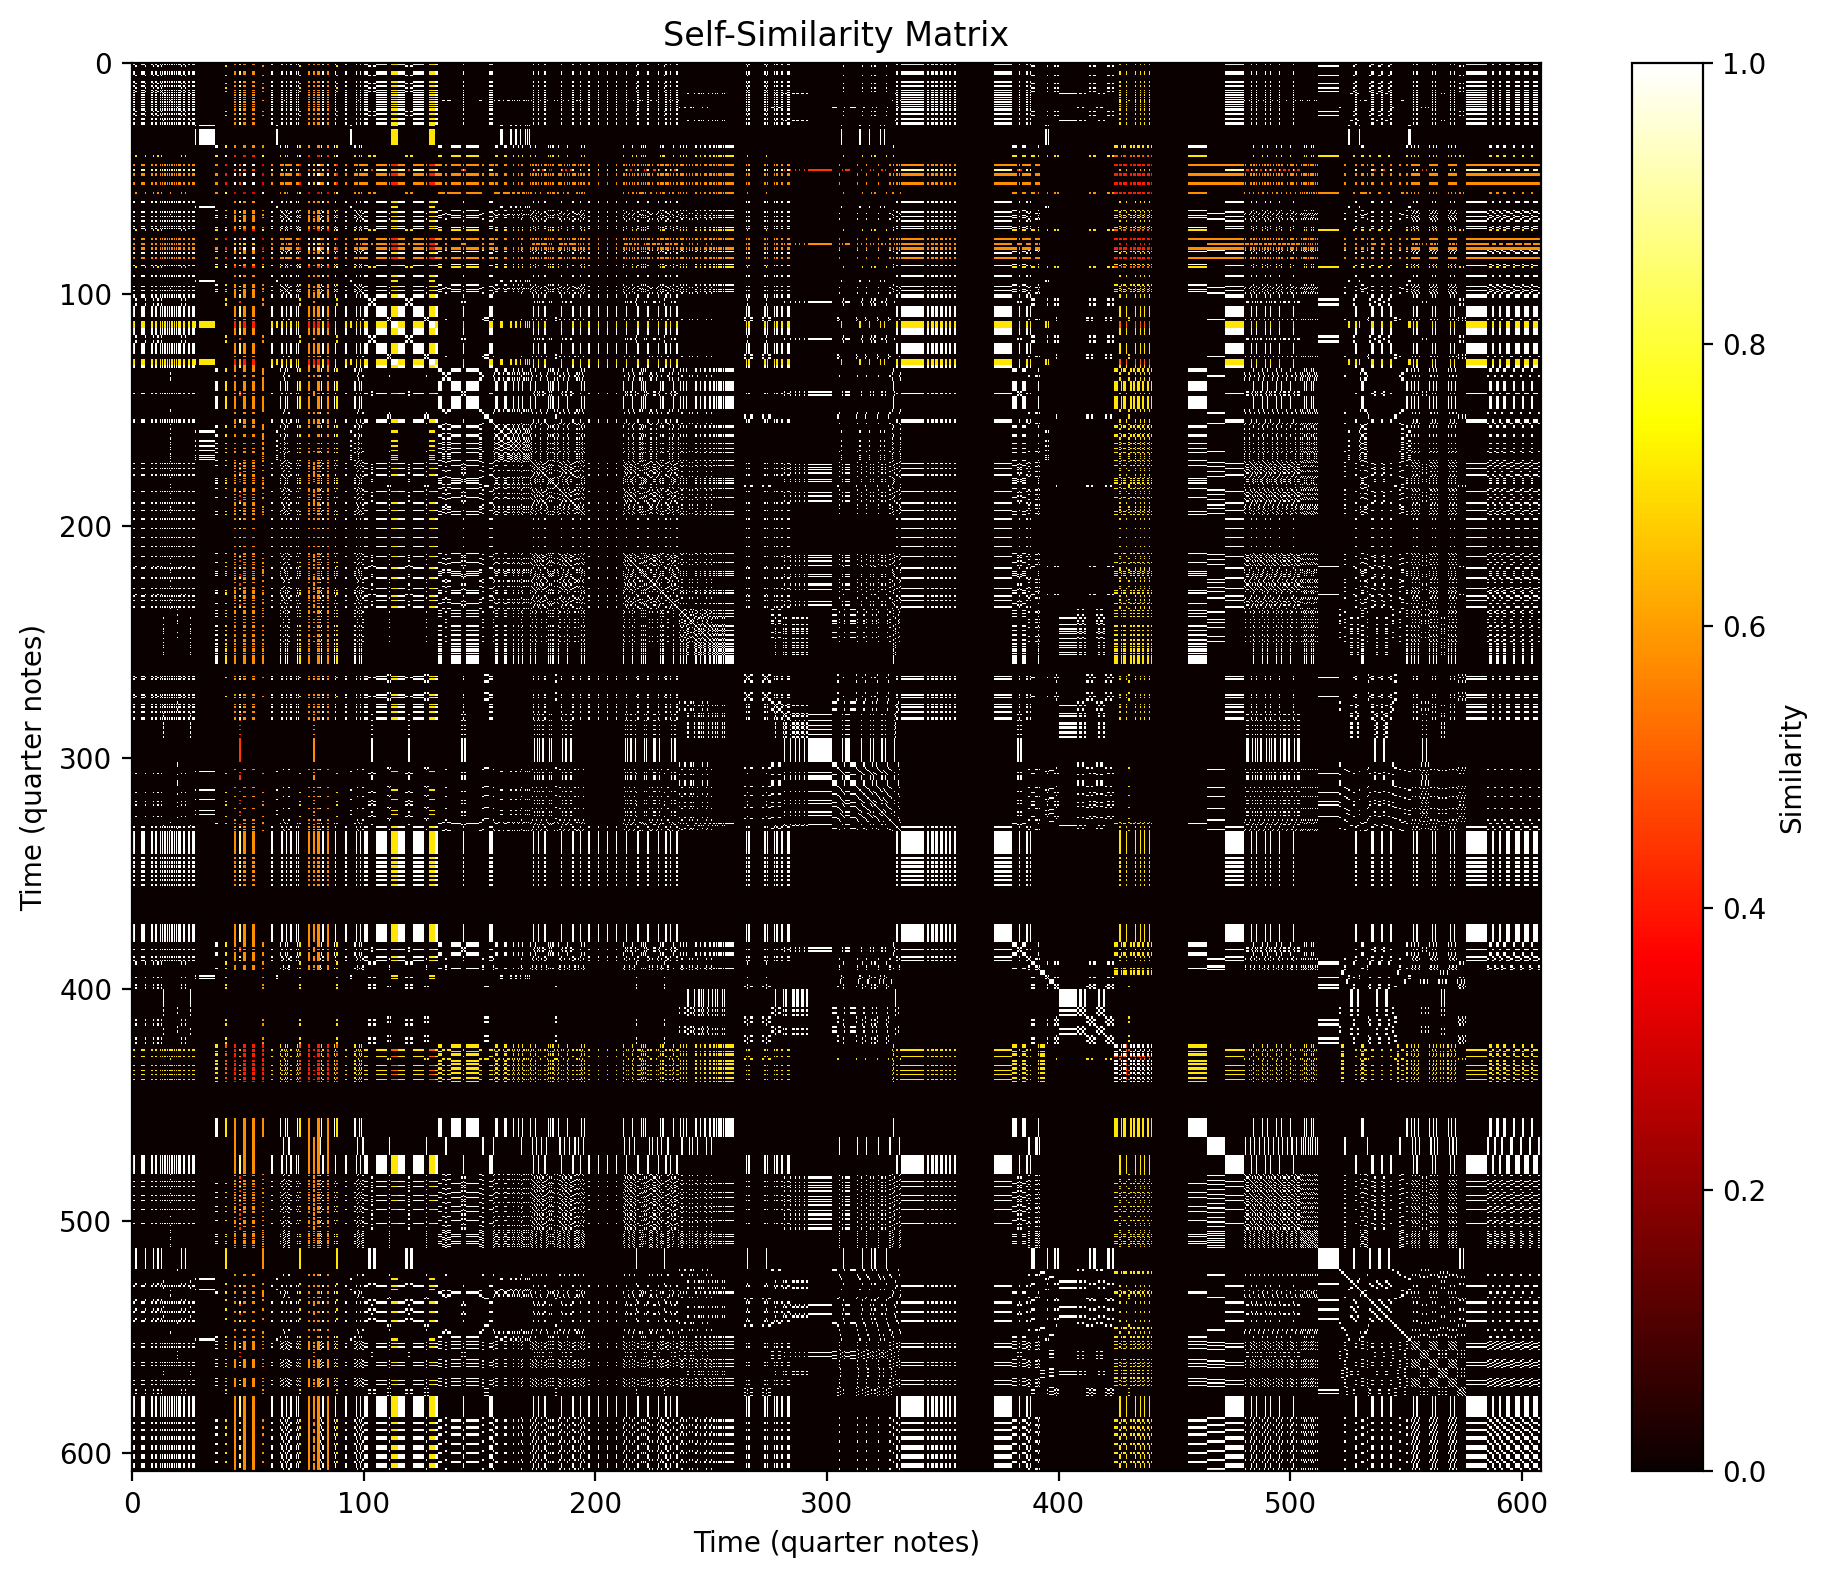

In [11]:
plot_ssm(build_ssm(results, 'chroma', part_idx = 10), time_grid)

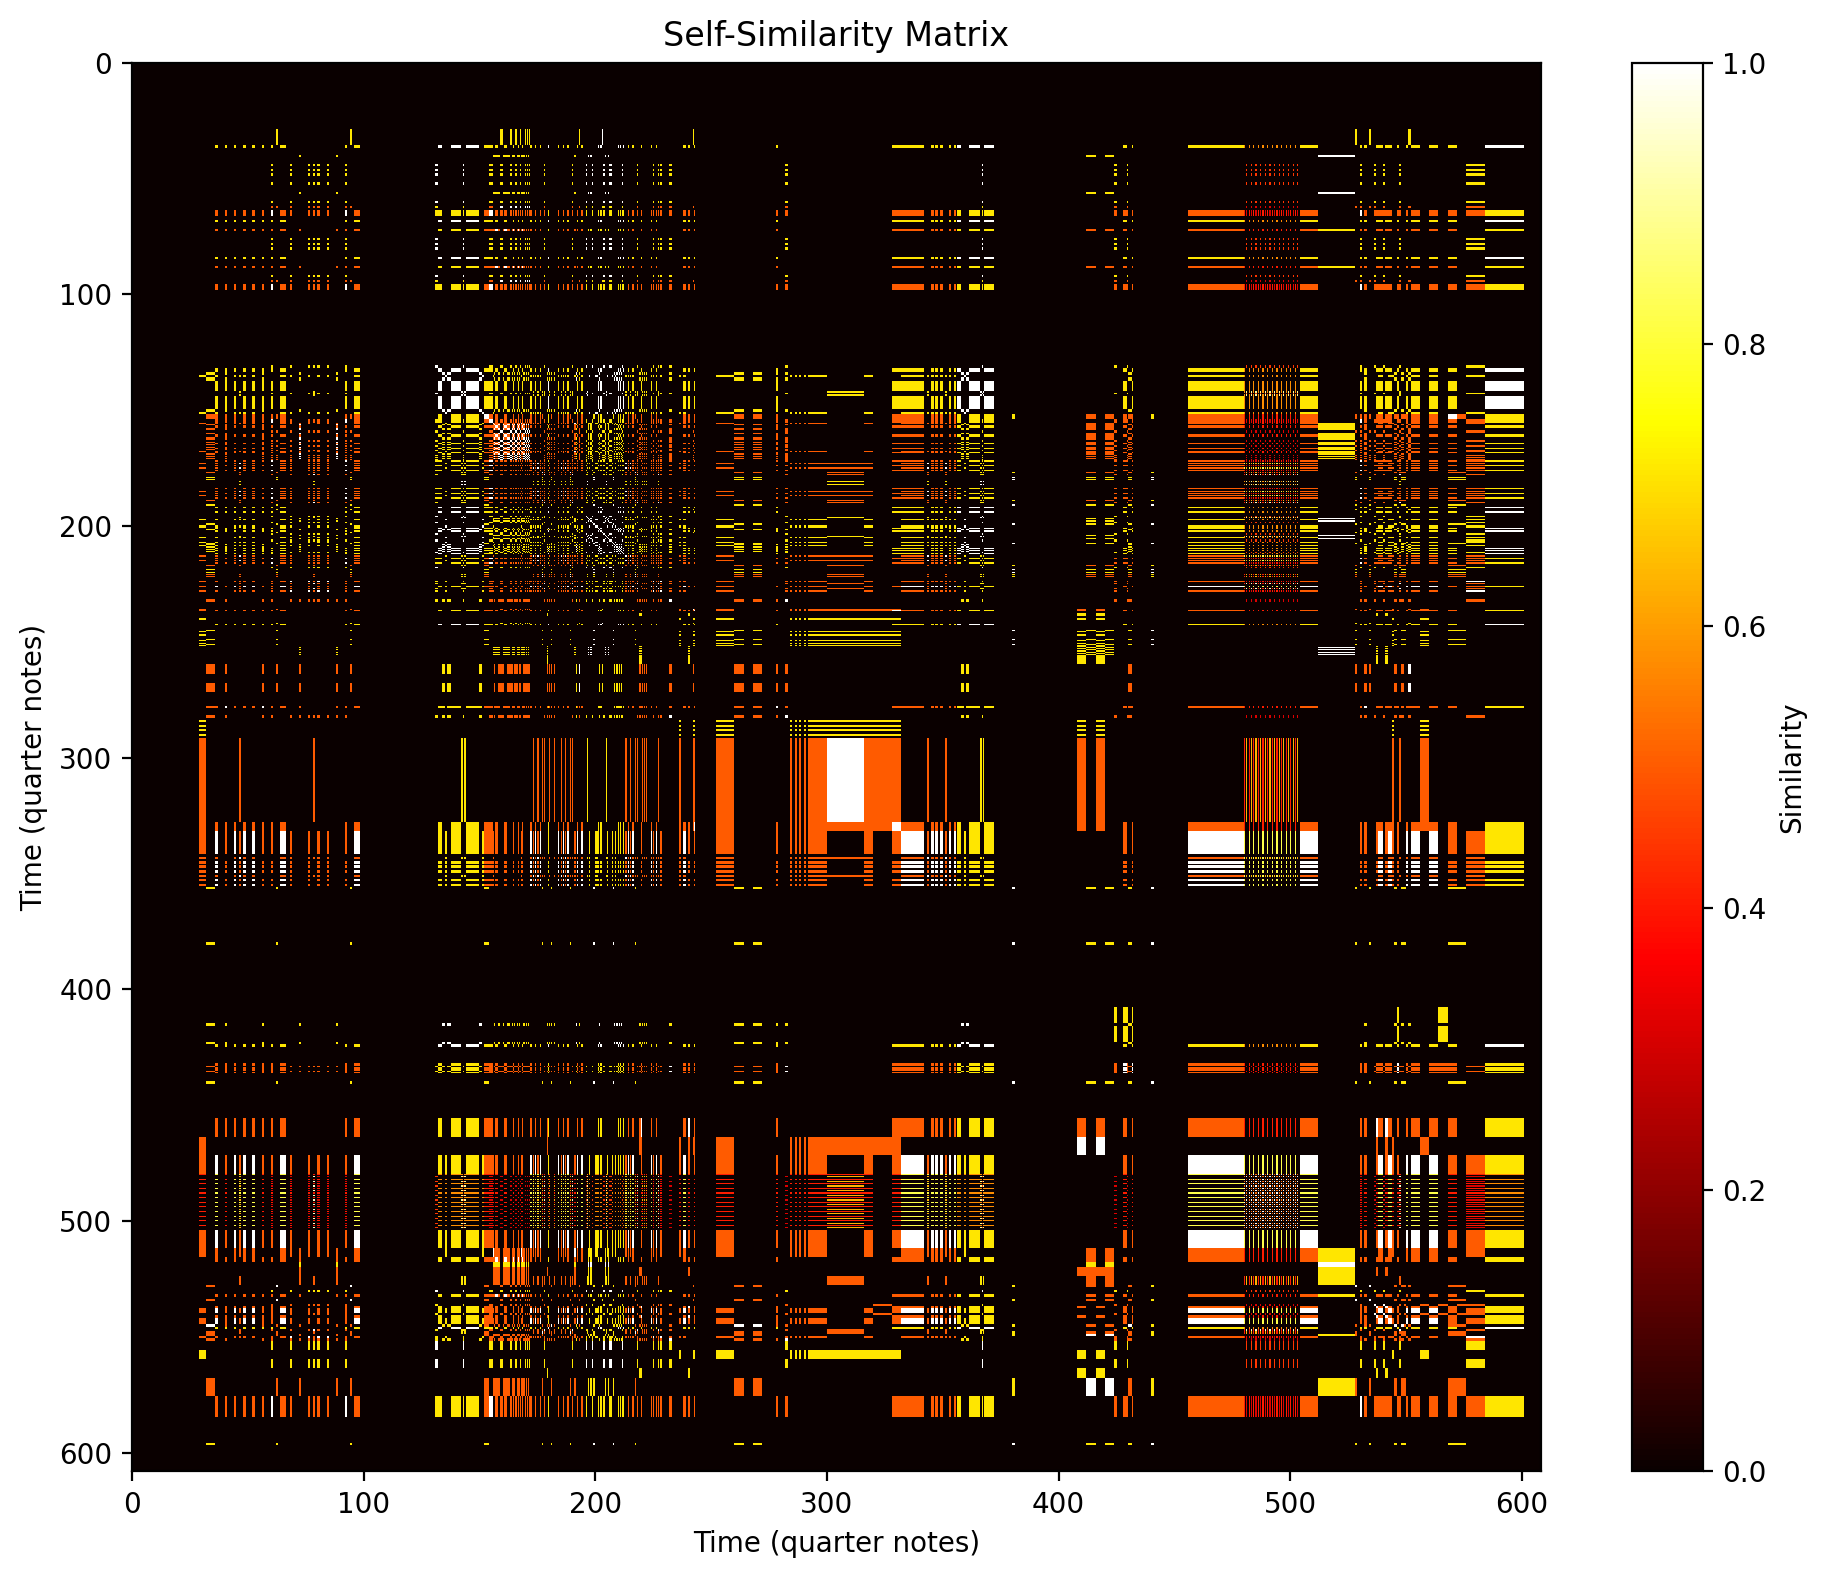

In [12]:
plot_ssm(build_ssm(results, 'chroma', part_idx = (0,1)), time_grid)

In [13]:
# Presumably then you use the SSM then to local where the sections are
# The problem is how to identify sections from discrete?
# Of course we can do it visually, but let's not do that, there are techniques like smoothing with Gaussian too
# But we could also just look at the music score and find clues.
# Either way, more work needs a doing and I will continue here with a novelty score computation here, which should detect "lines"
# See course notes

def compute_novelty(ssm, kernel_size=8):
    """
    Compute a novelty curve from the SSM by convolving a checkerboard kernel along the diagonal.
    Peaks in the novelty curve indicate points of significant structural change.
    """
    # Create a checkerboard kernel: positive on one diagonal, negative on the other
    kernel = np.ones((kernel_size, kernel_size))
    kernel = np.triu(kernel, 1) - np.tril(kernel, -1) # This creates the checkerboard pattern
    
    # Pad the SSM to avoid boundary issues
    pad_width = kernel_size // 2
    ssm_padded = np.pad(ssm, pad_width, mode='constant')
    
    novelty = np.zeros(len(ssm))
    for i in range(len(ssm)):
        # Extract a patch along the diagonal
        patch = ssm_padded[i:i+kernel_size, i:i+kernel_size]
        # Convolve with the kernel
        novelty[i] = np.sum(patch * kernel)
    
    return novelty

#novelty = compute_novelty(smoothed_ssm, kernel_size=32) # kernel size should match phrase length
def plot_novelty(novelty):
    plt.figure(figsize=(12, 4))
    plt.plot(time_grid[:len(novelty)], novelty)
    plt.title("Novelty Curve")
    plt.xlabel("Time (quarter notes)")
    plt.ylabel("Novelty Score")
    plt.axhline(y=0, color='r', linestyle='--')
    plt.show()

In [14]:
print(np.shape(build_ssm(results, 'chroma', part_idx = (0,0))))
print(np.shape(time_grid))

(2433, 2433)
(2433,)


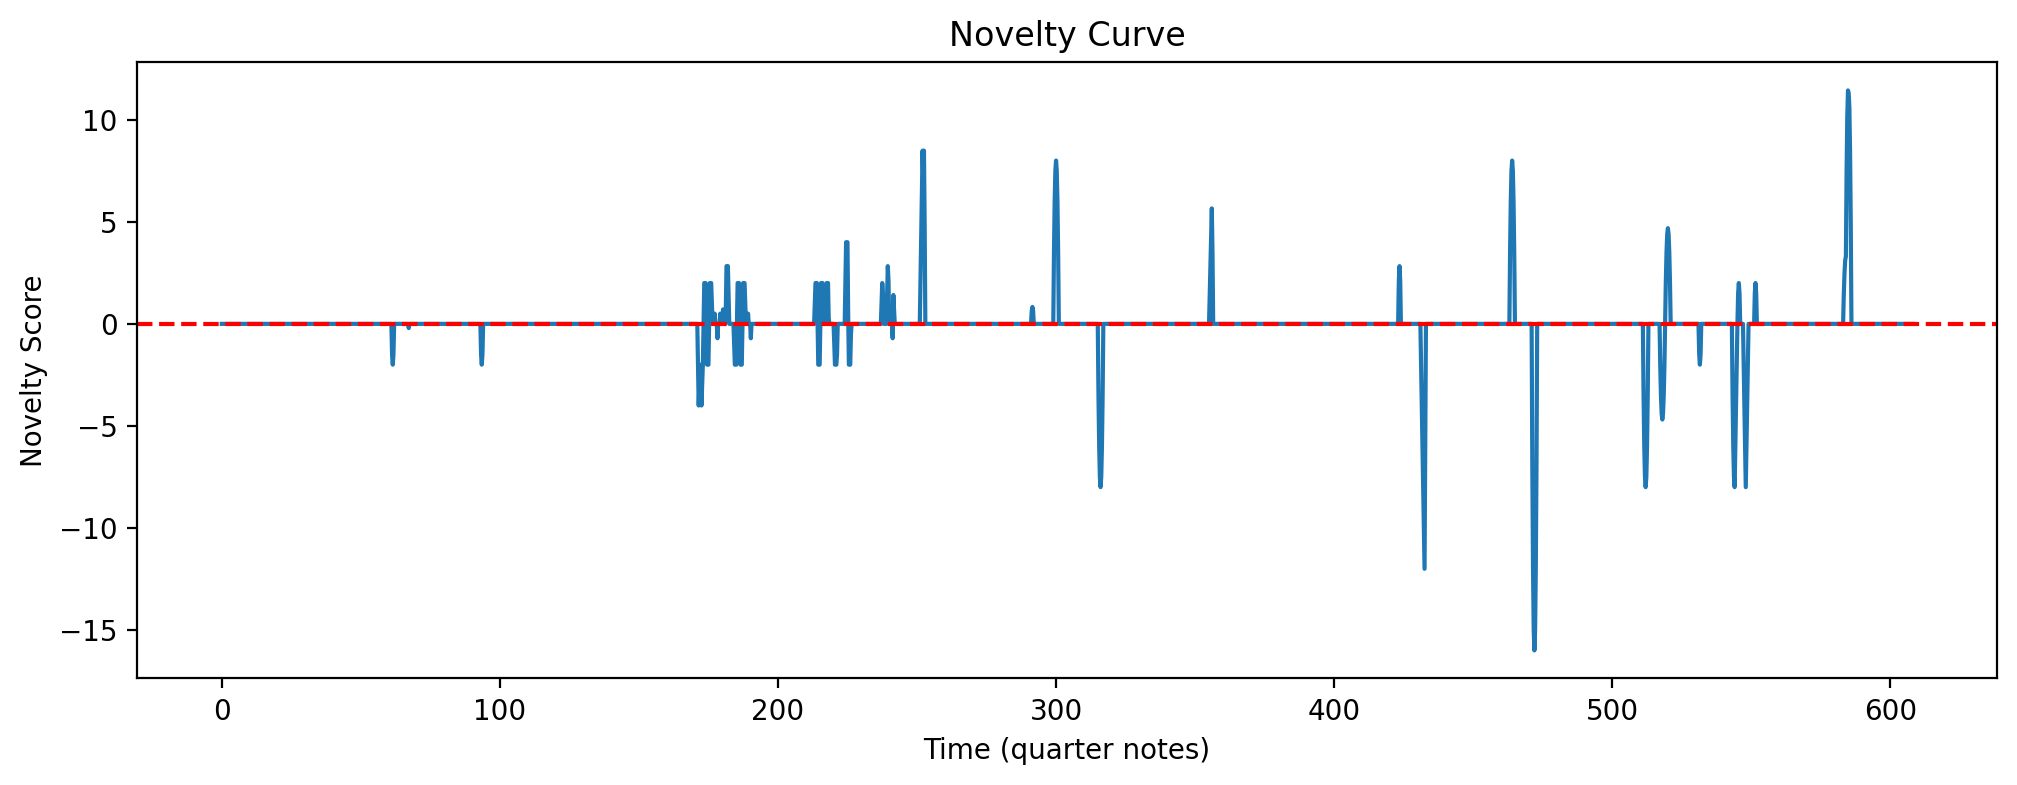

In [15]:
plot_novelty(compute_novelty(build_ssm(results, 'chroma', part_idx = (0,1))))

In [16]:
def detect_phrase_boundaries(score_path, division=16, kernel_size=32, 
                            peak_height=0.05, peak_distance=20, 
                            cluster_eps=0.5, cluster_min_samples=2):
    """
    Main function to detect phrase boundaries in a musical score.
    
    Args:
        score_path: Path to MusicXML file
        division: Number of divisions per quarter note
        kernel_size: Size of checkerboard kernel for novelty computation
        peak_height: Minimum height for peak detection
        peak_distance: Minimum distance between peaks
        cluster_eps: DBSCAN epsilon parameter (in quarter notes)
        cluster_min_samples: DBSCAN min_samples parameter
    
    Returns:
        boundary_times: List of detected boundary times in quarter notes
        novelty_curves: Dictionary of novelty curves for visualization
        all_peak_times: All detected peak times before clustering
    """
    # Parse the score and extract features
    score, parts, events = parse_musicxml(score_path)
    time_grid = create_musical_time_grid(score, division)
    features = extract_features_per_frame(parts, time_grid, division)
    
    # Generate all SSMs (self and cross)
    num_parts = len(parts)
    all_ssms = []
    
    # Self-SSMs
    for i in range(num_parts):
        all_ssms.append(build_ssm(features, 'chroma', part_idx=i))
    
    # Cross-SSMs
    for i in range(num_parts):
        for j in range(i+1, num_parts):
            all_ssms.append(build_ssm(features, 'chroma', part_idx=(i, j)))
    
    # Compute novelty curves and detect peaks
    all_peak_times = []
    novelty_curves = {}
    
    for idx, ssm in enumerate(all_ssms):
        novelty = compute_novelty(ssm, kernel_size)
        novelty_curves[idx] = novelty
        
        # Detect peaks in novelty curve
        peaks, _ = find_peaks(novelty, height=peak_height, distance=peak_distance)
        peak_times = time_grid[peaks]
        all_peak_times.extend(peak_times)
    
    # Cluster peak times
    if not all_peak_times:
        return [], novelty_curves, []
    
    X = np.array(all_peak_times).reshape(-1, 1)
    clustering = DBSCAN(eps=cluster_eps, min_samples=cluster_min_samples).fit(X)
    labels = clustering.labels_
    
    # Extract cluster centers (using median)
    boundary_times = []
    for label in set(labels):
        if label != -1:  # Ignore noise points
            cluster_points = X[labels == label].flatten()
            median_time = np.median(cluster_points)
            boundary_times.append(median_time)
    
    boundary_times.sort()
    
    # Refine boundaries using musical events (simplified version)
    refined_boundaries = refine_boundaries_with_events(boundary_times, events, time_grid)
    
    return refined_boundaries, novelty_curves, all_peak_times

In [17]:
def refine_boundaries_with_events(boundary_times, events, time_grid, max_search=0.5):
    """
    Refine boundaries by snapping them to nearby musical events.
    
    Args:
        boundary_times: Initial boundary times
        events: List of musical events (from parse_musicxml)
        time_grid: Time grid used for feature extraction
        max_search: Maximum distance to search for events (in quarter notes)
    
    Returns:
        refined_boundaries: Refined boundary times
    """
    # Extract event times (this would depend on your event extraction implementation)
    event_times = []
    for event in events:
        if hasattr(event, 'offset'):
            event_times.append(event.offset)
        # Add other event types as needed
    
    refined_boundaries = []
    for boundary in boundary_times:
        # Find nearest event within search radius
        nearest_event = None
        min_dist = float('inf')
        
        for event_time in event_times:
            dist = abs(event_time - boundary)
            if dist < min_dist and dist <= max_search:
                min_dist = dist
                nearest_event = event_time
        
        # Use the event time if found, otherwise keep the original boundary
        if nearest_event is not None:
            refined_boundaries.append(nearest_event)
        else:
            refined_boundaries.append(boundary)
    
    return sorted(refined_boundaries)

In [18]:
def visualize_novelty_curves(novelty_curves, time_grid, boundary_times=None):
    """
    Visualize all novelty curves and detected boundaries.
    
    Args:
        novelty_curves: Dictionary of novelty curves
        time_grid: Time grid
        boundary_times: List of boundary times to mark
    """
    num_curves = len(novelty_curves)
    fig, axes = plt.subplots(num_curves, 1, figsize=(12, 2*num_curves))
    
    if num_curves == 1:
        axes = [axes]
    
    for idx, (ssm_id, novelty) in enumerate(novelty_curves.items()):
        axes[idx].plot(time_grid[:len(novelty)], novelty)
        axes[idx].set_title(f"Novelty Curve for SSM {ssm_id}")
        axes[idx].set_xlabel("Time (quarter notes)")
        axes[idx].set_ylabel("Novelty")
        
        if boundary_times:
            for boundary in boundary_times:
                axes[idx].axvline(x=boundary, color='r', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [19]:
def segment_notes_by_boundaries(part, boundary_times):
    """
    Segment the notes of a part based on boundary times.
    
    Args:
        part: music21 Part object
        boundary_times: List of boundary times
    
    Returns:
        phrases: List of phrases, each phrase is a list of notes
    """
    phrases = [[] for _ in range(len(boundary_times) + 1)]
    current_phrase_idx = 0
    
    # Get all notes and chords in the part
    for element in part.flat.notesAndRests:
        if isinstance(element, (m21.note.Note, m21.chord.Chord, m21.note.Rest)):
            # Find which phrase this element belongs to
            while (current_phrase_idx < len(boundary_times) and 
                   element.offset >= boundary_times[current_phrase_idx]):
                current_phrase_idx += 1
            
            # Add element to current phrase
            if current_phrase_idx < len(phrases):
                phrases[current_phrase_idx].append(element)
    
    return phrases


In [ ]:
boundary_times, novelty_curves, all_peaks = detect_phrase_boundaries(
        "~/Dvorak_no9_colored_cut.mxl",
        division=16,
        kernel_size=32,      # Corresponds to 2 bars if division=16
        peak_height=0.05,
        peak_distance=40,    # Minimum 2.5 bars between peaks
        cluster_eps=0.5,     # Cluster within 0.5 quarter notes
        cluster_min_samples=2 # Require at least 2 SSMs to agree on a boundary
)
    
print(f"Detected {len(boundary_times)} phrase boundaries at: {boundary_times}")

/home/robbot/.local/lib/python3.13/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


In [ ]:
    
# Visualize novelty curves with boundaries
score, parts, events = parse_musicxml("~/Dvorak_no9_colored_cut.mxl")
time_grid = create_musical_time_grid(score, division=16)
visualize_novelty_curves(novelty_curves, time_grid, boundary_times)
    
    # Segment each part based on the boundaries
segmented_parts = []
for part in parts:
    phrases = segment_notes_by_boundaries(part, boundary_times)
    segmented_parts.append(phrases)
    
    # Now you have each part segmented into phrases
for i, part_phrases in enumerate(segmented_parts):
    print(f"Part {i} has {len(part_phrases)} phrases")
    for j, phrase in enumerate(part_phrases):
        print(f"  Phrase {j}: {len(phrase)} elements")
        